# Gesture Recognition (TO BE RUN IN GOOGLE COLAB)

In this project, we are going to build a 3D Conv model that will be able to predict the 5 gestures correctly. Please import the following libraries to get started.

Problem Statement
Imagine we are working as a data scientist at a home electronics company which manufactures state of the art smart televisions. We want to develop a cool feature in the smart-TV that can recognise five different gestures performed by the user which will help users control the TV without using a remote.
The gestures are continuously monitored by the webcam mounted on the TV. Each gesture corresponds to a specific command:

- Thumbs up:  Increase the volume
- Thumbs down: Decrease the volume
- Left swipe: 'Jump' backwards 10 seconds
- Right swipe: 'Jump' forward 10 seconds  
- Stop: Pause the movie


Each video is a sequence of 30 frames (or images).



In [1]:
import kagglehub
gesture_recognition_path = kagglehub.dataset_download('imsparsh/gesture-recognition')

Using Colab cache for faster access to the 'gesture-recognition' dataset.


In [2]:
print(gesture_recognition_path)

/kaggle/input/gesture-recognition


In [3]:
import numpy as np
import os
import imageio
from skimage.transform import resize, rescale
import datetime
import os

import matplotlib.pyplot as plt

from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, GRU, LSTM, Flatten, TimeDistributed, Flatten, BatchNormalization, Activation
from keras.layers import Conv3D, MaxPooling3D, Conv2D, MaxPooling2D
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.regularizers import l2
from keras import optimizers

We set the random seed so that the results don't vary drastically.

In [4]:
import tensorflow as tf
print(tf.__version__)
np.random.seed(30)
import random as rn
rn.seed(30)
from keras import backend as K
tf.random.set_seed(30)

2.19.0


In this block, you read the folder names for training and validation. You also set the `batch_size` here. Note that you set the batch size in such a way that you are able to use the GPU in full capacity. You keep increasing the batch size until the machine throws an error.

In [5]:
train_doc = np.random.permutation(open(gesture_recognition_path + '/train.csv').readlines())
val_doc = np.random.permutation(open(gesture_recognition_path + '/val.csv').readlines())
num_classes = 5  #number of softmax classes

In [6]:
curr_dt_time = datetime.datetime.now()
train_path = gesture_recognition_path + '/train'
val_path = gesture_recognition_path + '/val'
num_train_sequences = len(train_doc)
print('# training sequences =', num_train_sequences)
num_val_sequences = len(val_doc)
print('# validation sequences =', num_val_sequences)

# training sequences = 663
# validation sequences = 100


## Common Utils

Common utility to plot loss and accuracy

In [7]:
def plot_loss_accuracy(history):
    # list all data in history
    print(history.history.keys())
    # summarize history for accuracy
    plt.plot(history.history['categorical_accuracy'])
    plt.plot(history.history['val_categorical_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()
    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

Common utility to calculate steps

In [8]:
def calculate_steps(num_train_sequences, num_val_sequences, batch_size):
    if (num_train_sequences%batch_size) == 0:
        steps_per_epoch = int(num_train_sequences/batch_size)
    else:
        steps_per_epoch = (num_train_sequences//batch_size) + 1

    if (num_val_sequences%batch_size) == 0:
        validation_steps = int(num_val_sequences/batch_size)
    else:
        validation_steps = (num_val_sequences//batch_size) + 1

    return steps_per_epoch,validation_steps

Common utility for callbacks

In [9]:
def model_callbacks(folder_name):
    model_name = str(folder_name) + '_' + str(curr_dt_time).replace(' ','').replace(':','_') + '/'

    if not os.path.exists(model_name):
        os.mkdir(model_name)

    filepath = model_name + 'model-{epoch:05d}-{loss:.5f}-{categorical_accuracy:.5f}-{val_loss:.5f}-{val_categorical_accuracy:.5f}.h5'

    checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True, save_weights_only=False, mode='auto', save_freq='epoch')

    LR = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=0.0001, cooldown=1, verbose=1) # write the REducelronplateau code here

    return [checkpoint, LR]

## Generator
This is one of the most important part of the code. The overall structure of the generator has been given. In the generator, we are going to preprocess the images as you have images of 2 different dimensions as well as create a batch of video frames. we have to experiment with `img_idx`, `y`,`z` and normalization such that we get high accuracy.

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1047: UserWarning: This ImageDataGenerator specifies `zca_whitening`, which overrides setting of `featurewise_center`.
  warnings.warn(
/tmp/ipython-input-721/549507304.py:12: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image1 = imageio.imread(gesture_recognition_path + "/train/WIN_20180907_15_35_09_Pro_Right Swipe_new/WIN_20180907_15_35_09_Pro_00012.png")
/tmp/ipython-input-721/549507304.py:14: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image2 = imageio.imread(gesture_recognition_path + "/val/WIN_20

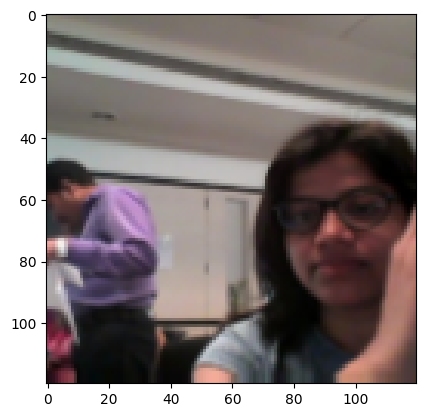

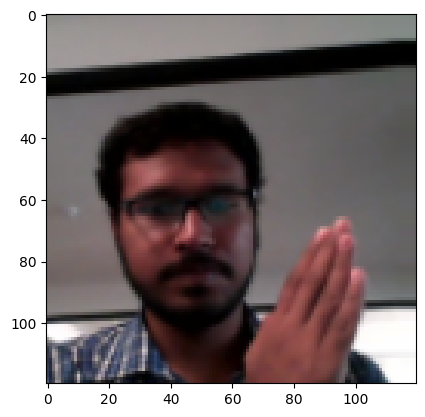

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#from keras.preprocessing.image import smart_resize

datagen = ImageDataGenerator(
    zoom_range=0.1,
    zca_whitening=True,
    width_shift_range=0.1,
    height_shift_range=0.1)

## Test code start
#360 by 360
image1 = imageio.imread(gesture_recognition_path + "/train/WIN_20180907_15_35_09_Pro_Right Swipe_new/WIN_20180907_15_35_09_Pro_00012.png")
#160 by 120
image2 = imageio.imread(gesture_recognition_path + "/val/WIN_20180907_15_30_06_Pro_Right Swipe_new/WIN_20180907_15_30_06_Pro_00015.png")
#crop the images and resize them. Note that the images are of 2 different shape
#and the conv3D will throw error if the inputs in a batch have different shapes
#print(image1.shape, image2.shape)
image1 = resize(image1, (120, 120), anti_aliasing=True)
image1 = datagen.random_transform(image1)
plt.imshow(image1)
plt.show()
image2 = resize(image2, (120, 120), anti_aliasing=True)
image2 = datagen.random_transform(image2)
plt.imshow(image2)
plt.show()
## Test code end

def generate(source_path, folder_list, batch_size, num_images=20, height=120, width=120, augment=False):
    #print( 'Source path = ', source_path, '; batch size =', batch_size)
    total_frames = 30

    while True:
        t = np.random.permutation(folder_list)
        num_batches = len(t)//batch_size # calculate the number of batches
        #img_idx = sorted(rn.sample(range(0, total_frames), num_images)) #create a list of image numbers you want to use for a particular video
        img_idx = np.round(np.linspace(0,total_frames-1,num_images)).astype(int) #create a list of image numbers you want to use for a particular video

        for batch in range(num_batches): # we iterate over the number of batches
            batch_data   = np.zeros((batch_size, num_images, height, width, 3)) # 3 is the number of channels RGB
            batch_labels = np.zeros((batch_size, 5)) # batch_labels is the one hot representation of the output

            for folder in range(batch_size): # iterate over the batch_size
                imgs = os.listdir(source_path+'/'+ t[folder + (batch*batch_size)].split(';')[0]) # read all the images in the folder
                for idx,item in enumerate(img_idx): #  Iterate over the frames/images of a folder to read them in
                    image = imageio.imread(source_path+'/'+ t[folder + (batch*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)

                    #crop the images and resize them. Note that the images are of 2 different shape
                    #and the conv3D will throw error if the inputs in a batch have different shapes
                    h, w, c = image.shape
                    image = resize(image, (height, width), anti_aliasing=True)

                    # Randomly transform few images of few folders; note that folders are randomly shuffled in each epoch too
                    if augment:
                        if np.random.randn() > 0:
                            image = datagen.random_transform(image)

                    batch_data[folder,idx,:,:,0] = (image[...,0])/255 #normalise and feed in the image
                    batch_data[folder,idx,:,:,1] = (image[...,1])/255 #normalise and feed in the image
                    batch_data[folder,idx,:,:,2] = (image[...,2])/255 #normalise and feed in the image

                batch_labels[folder, int(t[folder + (batch*batch_size)].strip().split(';')[2])] = 1

            yield batch_data, batch_labels #you yield the batch_data and the batch_labels, remember what does yield do

        # write the code for the remaining data points which are left after full batches
        if (len(t)%batch_size):
            remaining_batch_size = len(t)%batch_size
            batch_data   = np.zeros((remaining_batch_size, num_images, height, width,3)) # 3 is the number of channels RGB
            batch_labels = np.zeros((remaining_batch_size,5)) # batch_labels is the one hot representation of the output

            for folder in range(remaining_batch_size): # iterate over the batch_size
                imgs = os.listdir(source_path+'/'+ t[folder + (num_batches*batch_size)].split(';')[0]) # read all the images in the folder
                for idx,item in enumerate(img_idx): #  Iterate iver the frames/images of a folder to read them in
                    image = imageio.imread(source_path+'/'+ t[folder + (num_batches*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)

                    #crop the images and resize them. Note that the images are of 2 different shape
                    #and the conv3D will throw error if the inputs in a batch have different shapes
                    h, w, c = image.shape
                    image = resize(image, (height, width), anti_aliasing=True)

                    # Randomly transform few images of few folders; note that folders are randomly shuffled in each epoch too
                    if augment:
                        if np.random.randn() > 0:
                            image = datagen.random_transform(image)

                    batch_data[folder,idx,:,:,0] = (image[...,0])/255 #normalise and feed in the image
                    batch_data[folder,idx,:,:,1] = (image[...,1])/255 #normalise and feed in the image
                    batch_data[folder,idx,:,:,2] = (image[...,2])/255 #normalise and feed in the image

                batch_labels[folder, int(t[folder + (num_batches*batch_size)].strip().split(';')[2])] = 1

            yield batch_data, batch_labels #you yield the batch_data and the batch_labels, remember what does yield do


Note here that a video is represented above in the generator as (number of images, height, width, number of channels). Take this into consideration while creating the model architecture.

## Model
Here we make the model using different functionalities that Keras provides. We will use `Conv3D` and `MaxPooling3D` and not `Conv2D` and `Maxpooling2D` for a 3D convolution model. We would want to use `TimeDistributed` while building a Conv2D + RNN model. Also remember that the last layer is the softmax. We will Design the network in such a way that the model is able to give good accuracy on the least number of parameters so that it can fit in the memory of the webcam.

In [11]:
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, GRU, LSTM, Flatten, TimeDistributed, Flatten, BatchNormalization, Activation
from keras.layers import Conv3D, MaxPooling3D, Conv2D, MaxPooling2D
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.regularizers import l2
from keras import optimizers

### Conv3d Models

In [12]:
# Common utility to create conv 3D models
def conv3D(conv_filters=(16, 32, 64, 128), dense_nodes=(256,128), dropout=0.25, num_images=20, height=120, width=120):

    model = Sequential()

    model.add(Conv3D(conv_filters[0], (3, 3, 3), padding='same', input_shape=(num_images, height, width, 3)))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2)))

    model.add(Conv3D(conv_filters[1], (3, 3, 3), padding='same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2)))

    model.add(Conv3D(conv_filters[2], (3, 3, 3), padding='same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2)))

    model.add(Conv3D(conv_filters[3], (3, 3, 3), padding='same'))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2)))

    model.add(Flatten())
    model.add(Dense(dense_nodes[0]))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))

    model.add(Dense(dense_nodes[1]))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))

    model.add(Dense(num_classes))
    model.add(Activation('softmax'))

    opt = tf.keras.optimizers.Adam() #write your optimizer
    model.compile(opt, loss='categorical_crossentropy', metrics=['categorical_accuracy'])

    return model

#### Model 1: Conv 3D Model with 30 frames per video (16, 32, 64, 128 filters conv 3D layers + 256 dense layer + 128 dense layer + image size 120 by 120)


In [13]:
num_epochs = 20 # choose the number of epochs
print ('# epochs =', num_epochs)
batch_size = 10  #experiment with the batch size
print ('# batch size =', batch_size)
num_frames = 30
print ('# num_frames per video =', num_frames)
height = 120
width = 120

model = conv3D(num_images=num_frames)

print (model.summary())

# epochs = 20
# batch size = 10
# num_frames per video = 30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 30, 120, 120,   │         1,312 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 120, 120,   │             0 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 120, 120,   │            64 │
│ (BatchNormalization)            │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 15, 60, 60, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 15, 60, 60, 32) │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 15, 60, 60, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 60, 60, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 7, 30, 30, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 7, 30, 30, 64)  │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 30, 30, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 30, 30, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 3, 15, 15, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 3, 15, 15, 128) │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 3, 15, 15, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 3, 15, 15, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_3 (MaxPooling3D)  │ (None, 1, 7, 7, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,933,765 (7.38 MB)

 Trainable params: 1,932,517 (7.37 MB)

 Non-trainable params: 1,248 (4.88 KB)

None


The `steps_per_epoch` and `validation_steps` are used by `fit_generator` to decide the number of next() calls it need to make.
Let us now fit the model. This will start training the model and with the help of the checkpoints, you'll be able to save the model at the end of each epoch.

In [14]:
callbacks_list = model_callbacks("model_conv3D_1")

steps_per_epoch, validation_steps = calculate_steps(num_train_sequences, num_val_sequences, batch_size)

train_generator = generate(train_path, train_doc, batch_size, num_images=num_frames)

val_generator   = generate(val_path, val_doc, batch_size, num_images=num_frames)

In [15]:
history = model.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=num_epochs, verbose=1,
                             callbacks=callbacks_list, validation_data=val_generator,
                             validation_steps=validation_steps, class_weight=None, initial_epoch=0)

/tmp/ipython-input-721/549507304.py:45: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(source_path+'/'+ t[folder + (batch*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)


Epoch 1/20
66/67 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - categorical_accuracy: 0.3745 - loss: 1.8622

/tmp/ipython-input-721/549507304.py:74: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(source_path+'/'+ t[folder + (num_batches*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - categorical_accuracy: 0.3756 - loss: 1.8574
Epoch 1: val_loss improved from inf to 4.10217, saving model to model_conv3D_1_2026-03-0207_27_06.984709/model-00001-1.54123-0.45098-4.10217-0.16000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 347s 5s/step - categorical_accuracy: 0.3767 - loss: 1.8527 - val_categorical_accuracy: 0.1600 - val_loss: 4.1022 - learning_rate: 0.0010
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - categorical_accuracy: 0.5102 - loss: 1.1846
Epoch 2: val_loss did not improve from 4.10217
67/67 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - categorical_accuracy: 0.5106 - loss: 1.1846 - val_categorical_accuracy: 0.2300 - val_loss: 4.1477 - learning_rate: 0.0010
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - categorical_accuracy: 0.6163 - loss: 0.9892
Epoch 3: val_loss did not improve from 4.10217
67/67 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - categorical_accuracy: 0.6165 - loss: 0.9888 - val_categorical_accuracy: 0.2300 - val_loss: 4.2632 - learning_rate: 0.0010
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.4600 - loss: 1.4554
Epoch 4: val_loss improved from 4.10217 to 3.50603, saving model to model_conv3D_1_2026-03-0207_27_06.984709/model-00004-1.40246-

...

67/67 ━━━━━━━━━━━━━━━━━━━━ 196s 3s/step - categorical_accuracy: 0.8243 - loss: 0.4218 - val_categorical_accuracy: 0.7000 - val_loss: 0.8313 - learning_rate: 1.0000e-04
Epoch 12/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8696 - loss: 0.4005
Epoch 12: val_loss improved from 0.83129 to 0.66519, saving model to model_conv3D_1_2026-03-0207_27_06.984709/model-00012-0.41684-0.86124-0.66519-0.76000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - categorical_accuracy: 0.8695 - loss: 0.4007 - val_categorical_accuracy: 0.7600 - val_loss: 0.6652 - learning_rate: 1.0000e-04
Epoch 13/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8827 - loss: 0.3454
Epoch 13: val_loss improved from 0.66519 to 0.60178, saving model to model_conv3D_1_2026-03-0207_27_06.984709/model-00013-0.35280-0.86878-0.60178-0.80000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - categorical_accuracy: 0.8825 - loss: 0.3455 - val_categorical_accuracy: 0.8000 - val_loss: 0.6018 - learning_rate: 1.0000e-04
Epoch 14/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8896 - loss: 0.3157
Epoch 14: val_loss improved from 0.60178 to 0.54734, saving model to model_conv3D_1_2026-03-0207_27_06.984709/model-00014-0.35210-0.87783-0.54734-0.81000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - categorical_accuracy: 0.8894 - loss: 0.3163 - val_categorical_accuracy: 0.8100 - val_loss: 0.5473 - learning_rate: 1.0000e-04
Epoch 15/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8688 - loss: 0.3672
Epoch 15: val_loss did not improve from 0.54734
67/67 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - categorical_accuracy: 0.8687 - loss: 0.3671 - val_categorical_accuracy: 0.8100 - val_loss: 0.5538 - learning_rate: 1.0000e-04
Epoch 16/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8655 - loss: 0.3377
Epoch 16: val_loss did not improve from 0.54734
67/67 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - categorical_accuracy: 0.8656 - loss: 0.3375 - val_categorical_accuracy: 0.8300 - val_loss: 0.5873 - learning_rate: 1.0000e-04
Epoch 17/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8675 - loss: 0.3329
Epoch 17: val_loss improved from 0.54734 to 0.49093, saving model to model_conv3D_1_2026-03-0207_27_06.984709/mo

67/67 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - categorical_accuracy: 0.8675 - loss: 0.3329 - val_categorical_accuracy: 0.8700 - val_loss: 0.4909 - learning_rate: 1.0000e-04
Epoch 18/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - categorical_accuracy: 0.9065 - loss: 0.3240
Epoch 18: val_loss did not improve from 0.49093
67/67 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - categorical_accuracy: 0.9064 - loss: 0.3241 - val_categorical_accuracy: 0.8400 - val_loss: 0.5353 - learning_rate: 1.0000e-04
Epoch 19/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8866 - loss: 0.3246
Epoch 19: val_loss did not improve from 0.49093
67/67 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - categorical_accuracy: 0.8867 - loss: 0.3242 - val_categorical_accuracy: 0.7900 - val_loss: 0.5921 - learning_rate: 1.0000e-04
Epoch 20/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9073 - loss: 0.2929
Epoch 20: val_loss did not improve from 0.49093

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0001.
6

dict_keys(['categorical_accuracy', 'loss', 'val_categorical_accuracy', 'val_loss', 'learning_rate'])


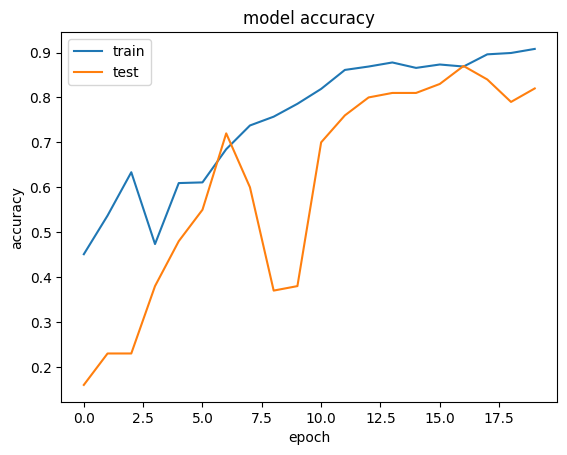

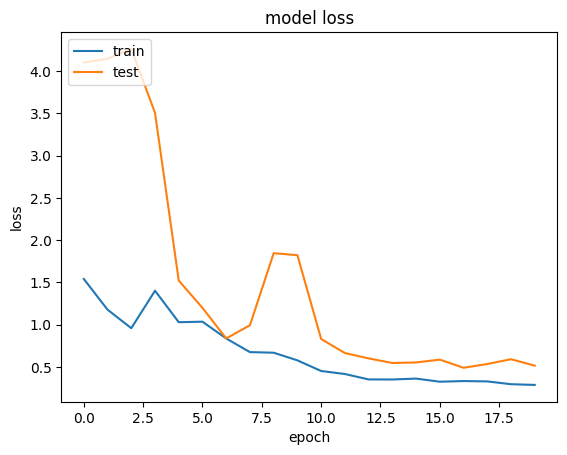

In [16]:
plot_loss_accuracy(history)

#### Model 2: Conv 3D Model with 20 frames per video (16, 32, 64, 128 filters conv 3D layers + 256 dense layer + 128 dense layer + image size 120 by 120)

In [17]:
num_epochs = 20 # choose the number of epochs
#print ('# epochs =', num_epochs)
batch_size = 10  #experiment with the batch size
print ('# batch size =', batch_size)
num_frames = 20
print ('# num_frames per video =', num_frames)
height = 120
width = 120

model = conv3D(num_images=num_frames)

print (model.summary())

# batch size = 10
# num_frames per video = 20


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_4 (Conv3D)               │ (None, 20, 120, 120,   │         1,312 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 20, 120, 120,   │             0 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 20, 120, 120,   │            64 │
│ (BatchNormalization)            │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_4 (MaxPooling3D)  │ (None, 10, 60, 60, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_5 (Conv3D)               │ (None, 10, 60, 60, 32) │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 10, 60, 60, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 10, 60, 60, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_5 (MaxPooling3D)  │ (None, 5, 30, 30, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_6 (Conv3D)               │ (None, 5, 30, 30, 64)  │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 5, 30, 30, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 5, 30, 30, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_6 (MaxPooling3D)  │ (None, 2, 15, 15, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_7 (Conv3D)               │ (None, 2, 15, 15, 128) │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 2, 15, 15, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 2, 15, 15, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_7 (MaxPooling3D)  │ (None, 1, 7, 7, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,933,765 (7.38 MB)

 Trainable params: 1,932,517 (7.37 MB)

 Non-trainable params: 1,248 (4.88 KB)

None


The `steps_per_epoch` and `validation_steps` are used by `fit_generator` to decide the number of next() calls it need to make.
Let us now fit the model. This will start training the model and with the help of the checkpoints, you'll be able to save the model at the end of each epoch.

In [18]:
callbacks_list = model_callbacks("model_conv3D_2")

steps_per_epoch, validation_steps = calculate_steps(num_train_sequences, num_val_sequences, batch_size)

train_generator = generate(train_path, train_doc, batch_size, num_images=num_frames)

val_generator   = generate(val_path, val_doc, batch_size, num_images=num_frames)

In [19]:
history = model.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=num_epochs, verbose=1,
                              callbacks=callbacks_list, validation_data=val_generator,
                              validation_steps=validation_steps, class_weight=None, initial_epoch=0)

/tmp/ipython-input-721/549507304.py:45: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(source_path+'/'+ t[folder + (batch*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)


Epoch 1/20
66/67 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - categorical_accuracy: 0.3932 - loss: 1.7611

/tmp/ipython-input-721/549507304.py:74: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(source_path+'/'+ t[folder + (num_batches*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.3939 - loss: 1.7583
Epoch 1: val_loss improved from inf to 2.79630, saving model to model_conv3D_2_2026-03-0207_27_06.984709/model-00001-1.57357-0.43590-2.79630-0.25000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - categorical_accuracy: 0.3945 - loss: 1.7556 - val_categorical_accuracy: 0.2500 - val_loss: 2.7963 - learning_rate: 0.0010
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.5643 - loss: 1.2208
Epoch 2: val_loss did not improve from 2.79630
67/67 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - categorical_accuracy: 0.5641 - loss: 1.2203 - val_categorical_accuracy: 0.1500 - val_loss: 6.8396 - learning_rate: 0.0010
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.5159 - loss: 1.2637
Epoch 3: val_loss did not improve from 2.79630
67/67 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - categorical_accuracy: 0.5165 - loss: 1.2616 - val_categorical_accuracy: 0.1300 - val_loss: 6.3097 - learning_rate: 0.0010
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.6673 - loss: 0.8156
Epoch 4: val_loss did not improve from 2.79630

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
67/6

...

67/67 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - categorical_accuracy: 0.7928 - loss: 0.5880 - val_categorical_accuracy: 0.7400 - val_loss: 0.7005 - learning_rate: 1.0000e-04
Epoch 13/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8499 - loss: 0.4049
Epoch 13: val_loss improved from 0.70048 to 0.61982, saving model to model_conv3D_2_2026-03-0207_27_06.984709/model-00013-0.38509-0.85973-0.61982-0.84000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - categorical_accuracy: 0.8501 - loss: 0.4046 - val_categorical_accuracy: 0.8400 - val_loss: 0.6198 - learning_rate: 1.0000e-04
Epoch 14/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8498 - loss: 0.3894
Epoch 14: val_loss improved from 0.61982 to 0.54212, saving model to model_conv3D_2_2026-03-0207_27_06.984709/model-00014-0.45033-0.83409-0.54212-0.81000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - categorical_accuracy: 0.8496 - loss: 0.3903 - val_categorical_accuracy: 0.8100 - val_loss: 0.5421 - learning_rate: 1.0000e-04
Epoch 15/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8636 - loss: 0.3597
Epoch 15: val_loss improved from 0.54212 to 0.52603, saving model to model_conv3D_2_2026-03-0207_27_06.984709/model-00015-0.37982-0.85370-0.52603-0.81000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - categorical_accuracy: 0.8635 - loss: 0.3600 - val_categorical_accuracy: 0.8100 - val_loss: 0.5260 - learning_rate: 1.0000e-04
Epoch 16/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8427 - loss: 0.4224
Epoch 16: val_loss did not improve from 0.52603
67/67 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - categorical_accuracy: 0.8430 - loss: 0.4219 - val_categorical_accuracy: 0.7200 - val_loss: 0.6154 - learning_rate: 1.0000e-04
Epoch 17/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8824 - loss: 0.2773
Epoch 17: val_loss did not improve from 0.52603
67/67 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - categorical_accuracy: 0.8825 - loss: 0.2774 - val_categorical_accuracy: 0.6900 - val_loss: 0.6528 - learning_rate: 1.0000e-04
Epoch 18/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8920 - loss: 0.2811
Epoch 18: val_loss improved from 0.52603 to 0.45566, saving model to model_conv3D_2_2026-03-0207_27_06.984709/mo

67/67 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - categorical_accuracy: 0.8922 - loss: 0.2808 - val_categorical_accuracy: 0.8300 - val_loss: 0.4557 - learning_rate: 1.0000e-04
Epoch 19/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9241 - loss: 0.2304
Epoch 19: val_loss did not improve from 0.45566
67/67 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - categorical_accuracy: 0.9236 - loss: 0.2312 - val_categorical_accuracy: 0.8200 - val_loss: 0.4755 - learning_rate: 1.0000e-04
Epoch 20/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9199 - loss: 0.2427
Epoch 20: val_loss did not improve from 0.45566
67/67 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - categorical_accuracy: 0.9200 - loss: 0.2426 - val_categorical_accuracy: 0.7900 - val_loss: 0.5256 - learning_rate: 1.0000e-04


dict_keys(['categorical_accuracy', 'loss', 'val_categorical_accuracy', 'val_loss', 'learning_rate'])


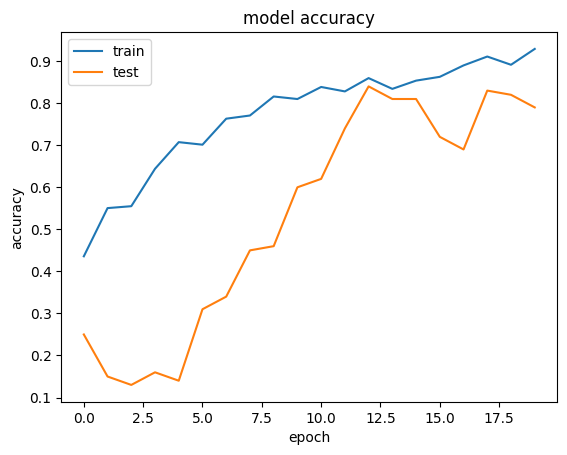

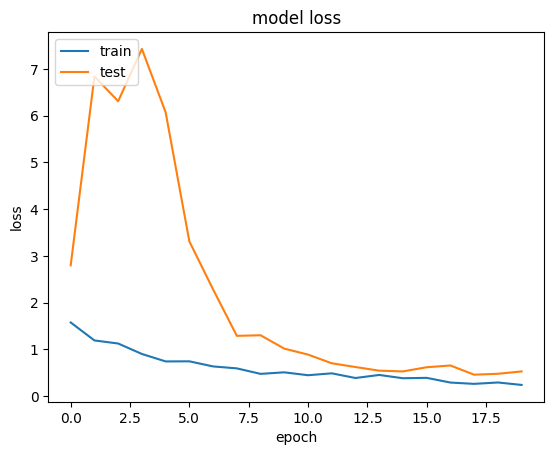

In [20]:
plot_loss_accuracy(history)

The `steps_per_epoch` and `validation_steps` are used by `fit_generator` to decide the number of next() calls it need to make.
Let us now fit the model. This will start training the model and with the help of the checkpoints, you'll be able to save the model at the end of each epoch.

#### Model 3: Conv 3D Model with 20 frames per video (16, 32, 64, 128 filters conv 3D layers + 256 dense layer + 128 dense layer + image size 160 by 160)

In [21]:
num_epochs = 20 # choose the number of epochs
print ('# epochs =', num_epochs)
batch_size = 10  #experiment with the batch size
print ('# batch size =', batch_size)
num_frames = 20
print ('# num_frames per video =', num_frames)
height = 160
width = 160

model = conv3D(num_images=num_frames, height=160, width=160)

print (model.summary())

# epochs = 20
# batch size = 10
# num_frames per video = 20


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_8 (Conv3D)               │ (None, 20, 160, 160,   │         1,312 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 20, 160, 160,   │             0 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 20, 160, 160,   │            64 │
│ (BatchNormalization)            │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_8 (MaxPooling3D)  │ (None, 10, 80, 80, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_9 (Conv3D)               │ (None, 10, 80, 80, 32) │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 10, 80, 80, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 10, 80, 80, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_9 (MaxPooling3D)  │ (None, 5, 40, 40, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_10 (Conv3D)              │ (None, 5, 40, 40, 64)  │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 5, 40, 40, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 5, 40, 40, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_10 (MaxPooling3D) │ (None, 2, 20, 20, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_11 (Conv3D)              │ (None, 2, 20, 20, 128) │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 2, 20, 20, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 2, 20, 20, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_11 (MaxPooling3D) │ (None, 1, 10, 10, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,604,933 (13.75 MB)

 Trainable params: 3,603,685 (13.75 MB)

 Non-trainable params: 1,248 (4.88 KB)

None


The `steps_per_epoch` and `validation_steps` are used by `fit_generator` to decide the number of next() calls it need to make.
Let us now fit the model. This will start training the model and with the help of the checkpoints, you'll be able to save the model at the end of each epoch.

In [22]:
callbacks_list = model_callbacks("model_conv3D_3")

steps_per_epoch, validation_steps = calculate_steps(num_train_sequences, num_val_sequences, batch_size)

train_generator = generate(train_path, train_doc, batch_size, num_images=num_frames, height=160, width=160)

val_generator   = generate(val_path, val_doc, batch_size, num_images=num_frames, height=160, width=160)

In [23]:
history = model.fit(train_generator, steps_per_epoch=steps_per_epoch, epochs=num_epochs, verbose=1,
                              callbacks=callbacks_list, validation_data=val_generator,
                              validation_steps=validation_steps, class_weight=None, initial_epoch=0)

/tmp/ipython-input-721/549507304.py:45: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(source_path+'/'+ t[folder + (batch*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)


Epoch 1/20
65/67 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - categorical_accuracy: 0.4043 - loss: 1.6980

/tmp/ipython-input-721/549507304.py:74: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(source_path+'/'+ t[folder + (num_batches*batch_size)].strip().split(';')[0]+'/'+imgs[item]).astype(np.float32)


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.4055 - loss: 1.6929
Epoch 1: val_loss improved from inf to 2.82666, saving model to model_conv3D_3_2026-03-0207_27_06.984709/model-00001-1.52525-0.44646-2.82666-0.23000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - categorical_accuracy: 0.4061 - loss: 1.6904 - val_categorical_accuracy: 0.2300 - val_loss: 2.8267 - learning_rate: 0.0010
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.5854 - loss: 1.0828
Epoch 2: val_loss did not improve from 2.82666
67/67 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - categorical_accuracy: 0.5856 - loss: 1.0824 - val_categorical_accuracy: 0.2600 - val_loss: 3.4293 - learning_rate: 0.0010
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.6497 - loss: 0.9222
Epoch 3: val_loss did not improve from 2.82666
67/67 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - categorical_accuracy: 0.6497 - loss: 0.9226 - val_categorical_accuracy: 0.2700 - val_loss: 3.0405 - learning_rate: 0.0010
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.5571 - loss: 1.0725
Epoch 4: val_loss improved from 2.82666 to 1.60396, saving model to model_conv3D_3_2026-03-0207_27_06.984709/model-00004-1.02921-

...

67/67 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - categorical_accuracy: 0.7441 - loss: 0.6135 - val_categorical_accuracy: 0.6400 - val_loss: 1.0101 - learning_rate: 0.0010
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8015 - loss: 0.5849
Epoch 8: val_loss did not improve from 1.01006
67/67 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - categorical_accuracy: 0.8013 - loss: 0.5850 - val_categorical_accuracy: 0.5800 - val_loss: 1.1436 - learning_rate: 0.0010
Epoch 9/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8588 - loss: 0.3963
Epoch 9: val_loss did not improve from 1.01006
67/67 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - categorical_accuracy: 0.8582 - loss: 0.3979 - val_categorical_accuracy: 0.3000 - val_loss: 4.2008 - learning_rate: 0.0010
Epoch 10/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8527 - loss: 0.4491
Epoch 10: val_loss did not improve from 1.01006

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
6

67/67 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - categorical_accuracy: 0.8875 - loss: 0.3160 - val_categorical_accuracy: 0.6800 - val_loss: 0.9103 - learning_rate: 1.0000e-04
Epoch 12/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8768 - loss: 0.3419
Epoch 12: val_loss improved from 0.91034 to 0.64472, saving model to model_conv3D_3_2026-03-0207_27_06.984709/model-00012-0.33679-0.87783-0.64472-0.71000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - categorical_accuracy: 0.8768 - loss: 0.3418 - val_categorical_accuracy: 0.7100 - val_loss: 0.6447 - learning_rate: 1.0000e-04
Epoch 13/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.8970 - loss: 0.3022
Epoch 13: val_loss did not improve from 0.64472
67/67 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - categorical_accuracy: 0.8969 - loss: 0.3022 - val_categorical_accuracy: 0.7400 - val_loss: 0.6944 - learning_rate: 1.0000e-04
Epoch 14/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9281 - loss: 0.2205
Epoch 14: val_loss improved from 0.64472 to 0.60080, saving model to model_conv3D_3_2026-03-0207_27_06.984709/model-00014-0.22416-0.91704-0.60080-0.79000.h5


67/67 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - categorical_accuracy: 0.9279 - loss: 0.2205 - val_categorical_accuracy: 0.7900 - val_loss: 0.6008 - learning_rate: 1.0000e-04
Epoch 15/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9042 - loss: 0.2755
Epoch 15: val_loss did not improve from 0.60080
67/67 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - categorical_accuracy: 0.9042 - loss: 0.2756 - val_categorical_accuracy: 0.7800 - val_loss: 0.6206 - learning_rate: 1.0000e-04
Epoch 16/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9245 - loss: 0.2315
Epoch 16: val_loss did not improve from 0.60080
67/67 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - categorical_accuracy: 0.9244 - loss: 0.2316 - val_categorical_accuracy: 0.7800 - val_loss: 0.6210 - learning_rate: 1.0000e-04
Epoch 17/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9455 - loss: 0.1994
Epoch 17: val_loss improved from 0.60080 to 0.51326, saving model to model_conv3D_3_2026-03-0207_27_06.984709/mo

67/67 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - categorical_accuracy: 0.9453 - loss: 0.1996 - val_categorical_accuracy: 0.7900 - val_loss: 0.5133 - learning_rate: 1.0000e-04
Epoch 18/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9260 - loss: 0.2230
Epoch 18: val_loss did not improve from 0.51326
67/67 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - categorical_accuracy: 0.9260 - loss: 0.2229 - val_categorical_accuracy: 0.8000 - val_loss: 0.5465 - learning_rate: 1.0000e-04
Epoch 19/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9235 - loss: 0.2032
Epoch 19: val_loss did not improve from 0.51326
67/67 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - categorical_accuracy: 0.9237 - loss: 0.2030 - val_categorical_accuracy: 0.7700 - val_loss: 0.5705 - learning_rate: 1.0000e-04
Epoch 20/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.9420 - loss: 0.2038
Epoch 20: val_loss did not improve from 0.51326

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0001.
6

dict_keys(['categorical_accuracy', 'loss', 'val_categorical_accuracy', 'val_loss', 'learning_rate'])


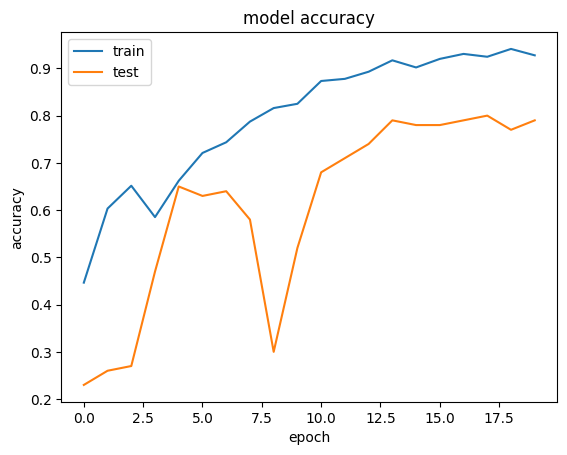

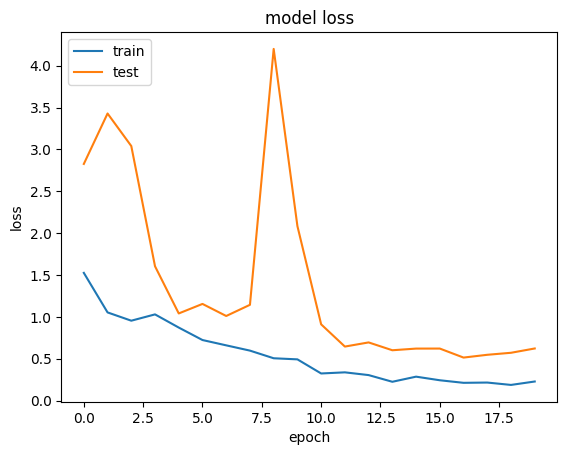

In [24]:
plot_loss_accuracy(history)

In [25]:
import datetime, pytz;
print("Current Time in IST:", datetime.datetime.now(pytz.utc).astimezone(pytz.timezone('Asia/Kolkata')).strftime('%Y-%m-%d %H:%M:%S'))

Current Time in IST: 2026-03-02 15:51:04


In [ ]:
# --- gcolab wrapper: list files in outputs/ ---
import os, datetime
_out_dir = 'outputs'
os.makedirs(_out_dir, exist_ok=True)
print(f"Files in {_out_dir}:")
_files = []
for _fn in os.listdir(_out_dir):
    _fp = os.path.join(_out_dir, _fn)
    if os.path.isfile(_fp):
        _st = os.stat(_fp)
        _files.append((datetime.datetime.fromtimestamp(_st.st_mtime).strftime('%Y-%m-%d %H:%M:%S'), _st.st_size, _fn))
_files.sort()
for _m, _s, _n in _files:
    if _s < 1024:
        _h = f"{_s} B"
    elif _s < 1024*1024:
        _h = f"{_s/1024:.2f} KB"
    else:
        _h = f"{_s/(1024*1024):.2f} MB"
    print(f"{_m}  {_h:>10}  {_n}")


In [ ]:
# --- gcolab wrapper: zip outputs/ -> outputs.zip ---
import os, shutil
os.makedirs('outputs', exist_ok=True)
shutil.make_archive('outputs', 'zip', 'outputs')
print('Created outputs.zip')
